# 02. Descriptive Statistics\n\nThis notebook is the second production stage and replaces the former Python script/notebook pair. It reads raw or prepared inputs, documents each validation exercise, and writes all final descriptive figures and tables directly to the flat figuresNtables folder.\n\nRun it once after 01_Preparation_v1.ipynb.


In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError("Could not locate the package directory containing data/.")
RAW_DIR = PROJECT_ROOT / "data" / "raw"
TABLES_DIR = PROJECT_ROOT / "figuresNtables"
FIGURES_DIR = PROJECT_ROOT / "figuresNtables"

SEPE_PATH = RAW_DIR / "sepe_cno4_monthly_ai_exposure.csv"
EPA_PATH = RAW_DIR / "ine_epa_parados_65218.csv"
EPA_URL = "https://www.ine.es/jaxiT3/files/t/csv_bdsc/65218.csv"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SEPE_PATH, EPA_PATH


(WindowsPath('C:/Users/ngonzalezp/OneDrive - AIREF/Escritorio/Unempolyment_Benefits/ai_unemployment_analysis/code/last_scripts/data/raw/sepe_cno4_monthly_ai_exposure.csv'),
 WindowsPath('C:/Users/ngonzalezp/OneDrive - AIREF/Escritorio/Unempolyment_Benefits/ai_unemployment_analysis/code/last_scripts/data/raw/ine_epa_parados_65218.csv'))

## Download EPA Unemployed Persons

The EPA table is INE table `65218`, "Parados por sexo y grupo de edad". We keep the aggregate row: age = `Total`, sex = `Ambos sexos`, unit = `Valor absoluto`. INE reports the level in thousands of persons, using Spanish numeric formatting.


In [2]:
if not EPA_PATH.exists():
    urlretrieve(EPA_URL, EPA_PATH)

print(f"EPA file: {EPA_PATH}")
print(f"SEPE file: {SEPE_PATH}")


EPA file: C:\Users\ngonzalezp\OneDrive - AIREF\Escritorio\Unempolyment_Benefits\ai_unemployment_analysis\code\last_scripts\data\raw\ine_epa_parados_65218.csv
SEPE file: C:\Users\ngonzalezp\OneDrive - AIREF\Escritorio\Unempolyment_Benefits\ai_unemployment_analysis\code\last_scripts\data\raw\sepe_cno4_monthly_ai_exposure.csv


In [3]:
def parse_spanish_number(value):
    """Parse INE/Spanish numeric strings such as '2.708,6' into floats."""
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text == "":
        return np.nan
    return float(text.replace(".", "").replace(",", "."))


def quarter_to_timestamp(q):
    """Convert strings like '2026T1' to quarter-end pandas timestamps."""
    year = int(str(q)[:4])
    quarter = int(str(q).split("T")[1])
    month = quarter * 3
    return pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)


def load_epa_unemployed(path=EPA_PATH):
    epa = pd.read_csv(path, sep=";", dtype=str)
    epa = epa.loc[
        epa["Edad"].eq("Total")
        & epa["Sexo"].eq("Ambos sexos")
        & epa["Unidad"].eq("Valor absoluto")
    ].copy()
    epa["epa_unemployed_thousands"] = epa["Total"].map(parse_spanish_number)
    epa["epa_unemployed_persons"] = epa["epa_unemployed_thousands"] * 1000
    epa["quarter"] = epa["Periodo"]
    epa["date"] = epa["quarter"].map(quarter_to_timestamp)
    return epa[["quarter", "date", "epa_unemployed_persons", "epa_unemployed_thousands"]].sort_values("date")


def load_sepe_registered_unemployed_quarterly(path=SEPE_PATH):
    usecols = ["period", "cno4", "dimension", "category", "gender", "parados"]
    chunks = []
    for chunk in pd.read_csv(path, usecols=usecols, dtype={"cno4": "string"}, chunksize=500_000):
        keep = (
            chunk["dimension"].eq("total")
            & chunk["category"].eq("Total")
            & chunk["gender"].eq("Total")
            & chunk["cno4"].str.len().eq(4)
        )
        sub = chunk.loc[keep, ["period", "cno4", "parados"]].copy()
        if not sub.empty:
            chunks.append(sub)
    sepe = pd.concat(chunks, ignore_index=True)
    sepe["parados"] = pd.to_numeric(sepe["parados"], errors="coerce")
    monthly = sepe.groupby("period", as_index=False)["parados"].sum()
    monthly["date"] = pd.to_datetime(monthly["period"] + "-01")

    quarterly = monthly.set_index("date")["parados"].resample("QE").mean().reset_index()
    quarterly["quarter"] = quarterly["date"].dt.year.astype(str) + "T" + quarterly["date"].dt.quarter.astype(str)
    quarterly = quarterly.rename(columns={"parados": "sepe_registered_unemployed_persons"})
    quarterly["sepe_registered_unemployed_millions"] = quarterly["sepe_registered_unemployed_persons"] / 1_000_000
    return quarterly[["quarter", "date", "sepe_registered_unemployed_persons", "sepe_registered_unemployed_millions"]]


epa_q = load_epa_unemployed()
sepe_q = load_sepe_registered_unemployed_quarterly()

validation = sepe_q.merge(epa_q, on=["quarter", "date"], how="inner")
validation["epa_unemployed_millions"] = validation["epa_unemployed_persons"] / 1_000_000
validation["sepe_minus_epa_millions"] = validation["sepe_registered_unemployed_millions"] - validation["epa_unemployed_millions"]
validation["sepe_to_epa_ratio"] = validation["sepe_registered_unemployed_persons"] / validation["epa_unemployed_persons"]

validation.head()


,quarter,date,sepe_registered_unemployed_persons,sepe_registered_unemployed_millions,epa_unemployed_persons,epa_unemployed_thousands,epa_unemployed_millions,sepe_minus_epa_millions,sepe_to_epa_ratio
0,2021T1,2021-03-31,3.974261e+06,3.974261,3703300.0,3703.3,3.7033,0.270961,1.073167
1,2021T2,2021-06-30,3.768739e+06,3.768739,3586400.0,3586.4,3.5864,0.182339,1.050842
2,2021T3,2021-09-30,3.336072e+06,3.336072,3467400.0,3467.4,3.4674,-0.131328,0.962125
3,2021T4,2021-12-31,3.181887e+06,3.181887,3148700.0,3148.7,3.1487,0.033187,1.010540
4,2022T1,2022-03-31,3.114508e+06,3.114508,3214700.0,3214.7,3.2147,-0.100192,0.968833


In [4]:
table_path = TABLES_DIR / "table_epa_vs_sepe_unemployment_quarterly.csv"
validation.to_csv(table_path, index=False)

summary = validation[["epa_unemployed_millions", "sepe_registered_unemployed_millions", "sepe_minus_epa_millions", "sepe_to_epa_ratio"]].describe()
corr = validation["epa_unemployed_millions"].corr(validation["sepe_registered_unemployed_millions"])

print(f"Saved table: {table_path}")
print(f"Correlation between EPA and SEPE series: {corr:.3f}")
summary


Saved table: C:\Users\ngonzalezp\OneDrive - AIREF\Escritorio\Unempolyment_Benefits\ai_unemployment_analysis\code\last_scripts\figuresNtables\table_epa_vs_sepe_unemployment_quarterly.csv
Correlation between EPA and SEPE series: 0.960


,epa_unemployed_millions,sepe_registered_unemployed_millions,sepe_minus_epa_millions,sepe_to_epa_ratio
count,21.000000,21.000000,21.000000,21.000000
mean,2.961733,2.858007,-0.103727,0.962452
std,0.334689,0.422266,0.138057,0.043722
min,2.477100,2.417594,-0.292409,0.898548
25%,2.754100,2.582930,-0.195606,0.931659
50%,2.894500,2.738774,-0.126903,0.962125
75%,3.148700,2.942025,-0.052675,0.979290
max,3.703300,3.974261,0.270961,1.073167


## Appendix Figure

The figure reports both series in millions of persons. SEPE registered unemployment is a registered administrative stock; EPA unemployment is a survey-based unemployment stock. The validation exercise is therefore about aggregate trend comparability, not equality of definitions.


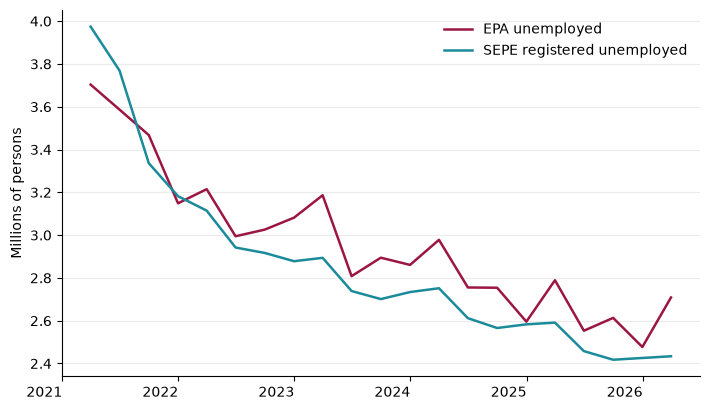

Saved figure: C:\Users\ngonzalezp\OneDrive - AIREF\Escritorio\Unempolyment_Benefits\ai_unemployment_analysis\code\last_scripts\figuresNtables\figure_epa_vs_sepe_unemployment_quarterly.png


In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))

ax.plot(
    validation["date"],
    validation["epa_unemployed_millions"],
    color="#9b1642",
    linewidth=1.8,
    label="EPA unemployed",
)
ax.plot(
    validation["date"],
    validation["sepe_registered_unemployed_millions"],
    color="#1b8a9a",
    linewidth=1.8,
    label="SEPE registered unemployed",
)

ax.set_ylabel("Millions of persons")
ax.set_xlabel("")
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.autofmt_xdate(rotation=0)
fig.tight_layout()

figure_path = FIGURES_DIR / "figure_epa_vs_sepe_unemployment_quarterly.png"
fig.savefig(figure_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved figure: {figure_path}")


## Occupation Coverage in the ANTHROPIC Exposure File

This section counts how many distinct occupations are present in the source file `anthropic_job_exposure_onet.csv`.


In [6]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError("Could not locate the package directory containing data/.")
CSV_PATH = PROJECT_ROOT / "data" / "raw" / "anthropic_job_exposure_onet.csv"

df = pd.read_csv(CSV_PATH)

unique_titles = df["title"].nunique(dropna=True)
unique_codes = df["occ_code"].nunique(dropna=True)

print(f"Rows in file: {len(df)}")
print(f"Unique occupations by title: {unique_titles}")
print(f"Unique occupations by OCC code: {unique_codes}")

df[["occ_code", "title"]].drop_duplicates().head()


Rows in file: 756
Unique occupations by title: 756
Unique occupations by OCC code: 756


,occ_code,title
0,11-1011,Chief Executives
1,11-1021,General and Operations Managers
2,11-1031,Legislators
3,11-2011,Advertising and Promotions Managers
4,11-2021,Marketing Managers


## Distribution of AI Exposure: U.S. ONET Occupations vs Spain-Mapped Occupations

This section compares the distribution of AI exposure values in the U.S. ONET file with the Spain-mapped occupation file. The U.S. series uses the `observed_exposure` variable from `anthropic_job_exposure_onet.csv`, while the Spain series uses `observed_exposure_cosine_nearest` from `sepe_cno4_monthly_ai_exposure.csv` after aggregating to one value per occupation.


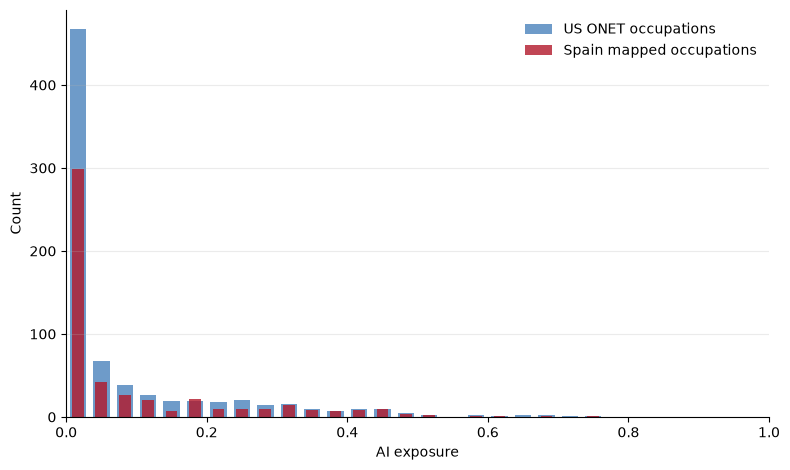

Figure saved to: C:\Users\ngonzalezp\OneDrive - AIREF\Escritorio\Unempolyment_Benefits\ai_unemployment_analysis\code\last_scripts\figuresNtables\figure_ai_exposure_distribution_us_vs_spain.png


In [7]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError("Could not locate the package directory containing data/.")
FIGURES_DIR = PROJECT_ROOT / "figuresNtables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_PATH = FIGURES_DIR / "figure_ai_exposure_distribution_us_vs_spain.png"

US_PATH = PROJECT_ROOT / "data" / "raw" / "anthropic_job_exposure_onet.csv"
SPAIN_PATH = PROJECT_ROOT / "data" / "raw" / "sepe_cno4_monthly_ai_exposure.csv"
us = pd.read_csv(US_PATH)
spain = pd.read_csv(SPAIN_PATH, dtype={"cno4": str})
us_series = pd.to_numeric(us["observed_exposure"], errors="coerce").dropna()
spain_series = (
    spain[["cno4", "observed_exposure_cosine_nearest"]]
    .drop_duplicates("cno4")["observed_exposure_cosine_nearest"]
    .pipe(pd.to_numeric, errors="coerce")
    .dropna()
)
bins = np.linspace(0, 1, 31)

fig, ax = plt.subplots(figsize=(8.0, 4.8))

# Compute histogram counts manually
us_counts, bin_edges = np.histogram(us_series, bins=bins)
spain_counts, _ = np.histogram(spain_series, bins=bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# Draw bars: US (wider, blue) then Spain (narrower, red) on top
ax.bar(
    bin_centers,
    us_counts,
    width=bin_width * 0.7,
    alpha=0.65,
    label="US ONET occupations",
    color="#2166ac",
)
ax.bar(
    bin_centers,
    spain_counts,
    width=bin_width * 0.5,
    alpha=0.80,
    label="Spain mapped occupations",
    color="#b2182b",
)

ax.set_xlabel("AI exposure")
ax.set_ylabel("Count")
ax.set_xlim(0, 1)
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_PATH, dpi=220, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {FIGURE_PATH}")


## Appendix tables: top 10 and bottom 10 exposure occupations

I would use the top 10 and bottom 10 occupations rather than percentile cutoffs. That makes the comparison directly comparable across countries and keeps the appendix tables concise and easy to read.


In [8]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError("Could not locate the package directory containing data/.")
RAW_DIR = PROJECT_ROOT / "data" / "raw"
TABLES_DIR = PROJECT_ROOT / "figuresNtables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

US_PATH = RAW_DIR / "anthropic_job_exposure_onet.csv"
SPAIN_PATH = RAW_DIR / "sepe_cno4_monthly_ai_exposure.csv"
OUTPUT_PATH = TABLES_DIR / "table_top_bottom_exposure_appendix.tex"


def escape_latex(text):
    if pd.isna(text):
        return ""
    text = str(text)
    return text.replace("&", r"\&").replace("%", r"\%").replace("_", r"\_").replace("#", r"\#")


SPANISH_TO_ENGLISH = {
    "Programadores informáticos": "Computer programmers",
    "Grabadores de datos": "Data entry clerks",
    "Agentes y representantes comerciales": "Sales agents and commercial representatives",
    "Analistas financieros": "Financial analysts",
    "Analistas y diseñadores de software y multimedia no clasificados bajo otros epígrafes": "Software and multimedia analysts and designers",
    "Empleados de oficina de servicios estadísticos, financieros y bancarios": "Statistical, financial, and banking office clerks",
    "Especialistas en bases de datos y en redes informáticas no clasificados bajo otros epígrafes": "Database and network specialists",
    "Técnicos de la web": "Web technicians",
    "Técnicos en asistencia al usuario de tecnologías de la información": "IT user-support technicians",
    "Profesionales de relaciones públicas": "Public relations professionals",
    "Oficiales de las fuerzas armadas": "Military officers",
    "Suboficiales de las fuerzas armadas": "Non-commissioned military officers",
    "Tropa y marinería de las fuerzas armadas": "Military enlisted personnel",
    "Miembros del poder ejecutivo (nacional, autonómico y local) y del poder legislativo": "Members of the executive and legislative branches",
    "Personal directivo de la administración pública": "Public administration executive staff",
    "Directores de recursos humanos": "Human resources directors",
    "Directores de producción de explotaciones agrarias": "Agricultural production directors",
}


def translate_occupation(text):
    if pd.isna(text):
        return ""
    text = str(text)
    return SPANISH_TO_ENGLISH.get(text, text)


def make_combined_table_tex(spain_df, us_df, top_n=10, bottom_n=10):
    spain_top = spain_df.nlargest(top_n, "exposure").copy().sort_values("exposure", ascending=False)
    spain_bottom = spain_df.nsmallest(bottom_n, "exposure").copy().sort_values("exposure", ascending=True)

    us_top = us_df.nlargest(top_n, "exposure").copy().sort_values("exposure", ascending=False)
    us_bottom = us_df.nsmallest(bottom_n, "exposure").copy().sort_values("exposure", ascending=True)

    top_rows = []
    for (_, spain_row), (_, us_row) in zip(spain_top.iterrows(), us_top.iterrows()):
        spain_title = translate_occupation(spain_row["occupation_description"])
        us_title = translate_occupation(us_row["occupation_description"])
        row = (
            f"{escape_latex(spain_row['code'])} & {escape_latex(spain_title)} & {spain_row['exposure']:.3f} & "
            f"{escape_latex(us_row['code'])} & {escape_latex(us_title)} & {us_row['exposure']:.3f} \\\\"
        )
        top_rows.append(row)

    bottom_rows = []
    for (_, spain_row), (_, us_row) in zip(spain_bottom.iterrows(), us_bottom.iterrows()):
        spain_title = translate_occupation(spain_row["occupation_description"])
        us_title = translate_occupation(us_row["occupation_description"])
        row = (
            f"{escape_latex(spain_row['code'])} & {escape_latex(spain_title)} & {spain_row['exposure']:.3f} & "
            f"{escape_latex(us_row['code'])} & {escape_latex(us_title)} & {us_row['exposure']:.3f} \\\\"
        )
        bottom_rows.append(row)

    top_panel = "\n".join(top_rows)
    bottom_panel = "\n".join(bottom_rows)

    template = r"""\begin{{table}}[H]
\centering
\caption{{Top and bottom {top_n} AI-exposure occupations in Spain and the United States}}
\label{{tab:top_bottom_exposure_comparison}}

\footnotesize

\begin{{adjustbox}}{{max width=\linewidth}}
\begin{{tabular}}{{
  l
  >{{\raggedright\arraybackslash}}p{{4.8cm}}
  r
  l
  >{{\raggedright\arraybackslash}}p{{7.0cm}}
  r
}}
\toprule
\multicolumn{{3}}{{c}}{{Spain (CNO4)}} &
\multicolumn{{3}}{{c}}{{United States (OCC code)}} \\
\cmidrule(lr){{1-3}}
\cmidrule(lr){{4-6}}
Code & Occupation & Exposure &
Code & Occupation & Exposure \\
\midrule

\multicolumn{{6}}{{c}}{{\textbf{{Panel A. Top {top_n} occupations}}}} \\
\midrule

{top_panel}
\midrule
\multicolumn{{6}}{{c}}{{\textbf{{Panel B. Bottom {bottom_n} occupations}}}} \\
\midrule

{bottom_panel}
\bottomrule
\end{{tabular}}
\end{{adjustbox}}

\vspace{{0.25cm}}

\begin{{minipage}}{{1\linewidth}}
\footnotesize
\textit{{Notes:}} The table reports the ten occupations with the highest and lowest AI exposure after mapping the Anthropic AI exposure measure to Spanish CNO4d occupations. U.S. occupations correspond to the original Anthropic ranking.

\smallskip

\textit{{Source:}} Own calculations based on SEPE, O*NET, and \citet{{anthropic_2026_labor_market}}.
\end{{minipage}}

\end{{table}}
"""

    return template.format(
        top_n=top_n,
        bottom_n=bottom_n,
        top_panel=top_panel,
        bottom_panel=bottom_panel,
    )


us_df = pd.read_csv(US_PATH)
us_df = us_df[["occ_code", "title", "observed_exposure"]].dropna(subset=["observed_exposure"]).copy()
us_df["exposure"] = pd.to_numeric(us_df["observed_exposure"], errors="coerce")
us_df = us_df.dropna(subset=["exposure"]).rename(columns={"occ_code": "code", "title": "occupation_description"})

spain_df = pd.read_csv(
    SPAIN_PATH,
    usecols=["cno4", "occupation_title", "dimension", "category", "gender", "observed_exposure_cosine_nearest"],
    dtype={"cno4": "string"},
)
spain_keep = (
    spain_df["dimension"].eq("total")
    & spain_df["category"].eq("Total")
    & spain_df["gender"].eq("Total")
)
spain_df = spain_df.loc[spain_keep, ["cno4", "occupation_title", "observed_exposure_cosine_nearest"]].copy()
spain_df["exposure"] = pd.to_numeric(spain_df["observed_exposure_cosine_nearest"], errors="coerce")
spain_df = spain_df.dropna(subset=["exposure"]).rename(columns={"cno4": "code", "occupation_title": "occupation_description"})
spain_df = spain_df.groupby(["code", "occupation_description"], as_index=False)["exposure"].mean()

combined_tex = make_combined_table_tex(spain_df, us_df)

OUTPUT_PATH.write_text(combined_tex, encoding="utf-8")

print(f"Saved combined LaTeX table to: {OUTPUT_PATH}")
print("\n--- Preview ---")
print(combined_tex[:1500])


Saved combined LaTeX table to: C:\Users\ngonzalezp\OneDrive - AIREF\Escritorio\Unempolyment_Benefits\ai_unemployment_analysis\code\last_scripts\figuresNtables\table_top_bottom_exposure_appendix.tex

--- Preview ---
\begin{table}[H]
\centering
\caption{Top and bottom 10 AI-exposure occupations in Spain and the United States}
\label{tab:top_bottom_exposure_comparison}

\footnotesize

\begin{adjustbox}{max width=\linewidth}
\begin{tabular}{
  l
  >{\raggedright\arraybackslash}p{4.8cm}
  r
  l
  >{\raggedright\arraybackslash}p{7.0cm}
  r
}
\toprule
\multicolumn{3}{c}{Spain (CNO4)} &
\multicolumn{3}{c}{United States (OCC code)} \\
\cmidrule(lr){1-3}
\cmidrule(lr){4-6}
Code & Occupation & Exposure &
Code & Occupation & Exposure \\
\midrule

\multicolumn{6}{c}{\textbf{Panel A. Top 10 occupations}} \\
\midrule

3820 & Computer programmers & 0.745 & 15-1251 & Computer Programmers & 0.745 \\
4301 & Data entry clerks & 0.671 & 43-4051 & Customer Service Representatives & 0.701 \\
3510 & Sales age

## Summary statistics

This table reports summary statistics for registered unemployment, new registered contracts, and the AI exposure indices in the filtered SEPE occupation dataset.


In [9]:
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError("Could not locate the package directory containing data/.")
RAW_DIR = PROJECT_ROOT / "data" / "raw"
TABLES_DIR = PROJECT_ROOT / "figuresNtables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

SEPE_PATH = RAW_DIR / "sepe_cno4_monthly_ai_exposure.csv"
OUTPUT_PATH = TABLES_DIR / "summary_statistics.tex"

sepe = pd.read_csv(
    SEPE_PATH,
    dtype={"cno4": "string"},
)

keep = (
    sepe["dimension"].eq("total")
    & sepe["category"].eq("Total")
    & sepe["gender"].eq("Total")
)
sepe = sepe.loc[keep].copy()

numeric_cols = [
    "parados",
    "contratos",
    "observed_exposure_cosine_nearest",
    "observed_exposure_cosine_weighted",
    "observed_exposure_rf",
]
for col in numeric_cols:
    sepe[col] = pd.to_numeric(sepe[col], errors="coerce")

sepe["log_parados"] = np.where(sepe["parados"] > 0, np.log(sepe["parados"]), np.nan)
sepe["log_contratos"] = np.where(sepe["contratos"] > 0, np.log(sepe["contratos"]), np.nan)

rows = [
    ("Registered unemployed (in levels)", "parados", False),
    ("New registered contracts (in levels)", "contratos", False),
    ("Registered unemployed (in logs)", "log_parados", False),
    ("New registered contracts (in logs)", "log_contratos", False),
    ("AI exposure index", None, True),  # Section header
    ("AI index - cosine similarity", "observed_exposure_cosine_nearest", False),
    ("AI index - cosine-weighted", "observed_exposure_cosine_weighted", False),
    ("AI index - random forest", "observed_exposure_rf", False),
]

def format_number(val):
    """Format number with thousands separator."""
    if np.isnan(val):
        return "0.000"
    return f"{val:,.3f}"

def format_obs_count(val):
    """Format observation count with thousands separator."""
    return f"{val:,}"

summary_lines = []

# Add "Outcomes" header row first
summary_lines.append("\\textbf{Outcomes} & & & & & \\\\\n")

# Add outcomes variables
for label in ["Registered unemployed (in levels)", "New registered contracts (in levels)", 
              "Registered unemployed (in logs)", "New registered contracts (in logs)"]:
    col = {"Registered unemployed (in levels)": "parados",
           "New registered contracts (in levels)": "contratos",
           "Registered unemployed (in logs)": "log_parados",
           "New registered contracts (in logs)": "log_contratos"}[label]
    
    series = sepe[col]
    mean = series.mean(skipna=True)
    sd = series.std(skipna=True, ddof=1)
    mn = series.min(skipna=True)
    mx = series.max(skipna=True)
    nobs = int(series.count())
    
    summary_lines.append(
        f"\\hspace{{0.3cm}} {label} & {format_number(mean)} & {format_number(sd)} & {format_number(mn)} & {format_number(mx)} & {format_obs_count(nobs)} \\\\\n"
    )

# Add "AI exposure index" header row
summary_lines.append("\\textbf{AI exposure index} & & & & & \\\\\n")

# Add AI exposure variables
for label, col in [("AI index - cosine similarity", "observed_exposure_cosine_nearest"),
                   ("AI index - cosine-weighted", "observed_exposure_cosine_weighted"),
                   ("AI index - random forest", "observed_exposure_rf")]:
    series = sepe[col]
    mean = series.mean(skipna=True)
    sd = series.std(skipna=True, ddof=1)
    mn = series.min(skipna=True)
    mx = series.max(skipna=True)
    nobs = int(series.count())
    
    summary_lines.append(
        f"\\hspace{{0.3cm}} {label} & {format_number(mean)} & {format_number(sd)} & {format_number(mn)} & {format_number(mx)} & {format_obs_count(nobs)} \\\\\n"
    )

body = "".join(summary_lines)

tex = r"""\begin{table}[H]
\centering
\caption{Summary statistics for SEPE occupation-level variables and AI exposure indices}
\label{tab:summary_statistics}
\footnotesize
\begin{tabular}{lrrrrr}
\toprule
 & mean & sd & min & max & obs. \\
\midrule
{body}\bottomrule
\end{tabular}
\begin{tablenotes}
\small
\item \textit{Sources:} Labor-market data come from SEPE (Servicio Público de Empleo Estatal). The occupation-level AI exposure measure is based on a mapping of Anthropic/O*NET occupations to four-digit occupations in the Spanish National Classification of Occupations 2011 (CNO-11).
\end{tablenotes}
\end{table}
"""

OUTPUT_PATH.write_text(tex.replace("{body}", body), encoding="utf-8")

print(f"Saved summary statistics table to: {OUTPUT_PATH}")
print("\n--- Preview ---")
print(tex.replace("{body}", body))


Saved summary statistics table to: C:\Users\ngonzalezp\OneDrive - AIREF\Escritorio\Unempolyment_Benefits\ai_unemployment_analysis\code\last_scripts\figuresNtables\summary_statistics.tex

--- Preview ---
\begin{table}[H]
\centering
\caption{Summary statistics for SEPE occupation-level variables and AI exposure indices}
\label{tab:summary_statistics}
\footnotesize
\begin{tabular}{lrrrrr}
\toprule
 & mean & sd & min & max & obs. \\
\midrule
\textbf{Outcomes} & & & & & \\
\hspace{0.3cm} Registered unemployed (in levels) & 5,693.240 & 25,338.023 & 0.000 & 467,292.000 & 31,626 \\
\hspace{0.3cm} New registered contracts (in levels) & 2,776.130 & 11,080.937 & 0.000 & 216,727.000 & 31,626 \\
\hspace{0.3cm} Registered unemployed (in logs) & 6.718 & 1.944 & 0.000 & 13.055 & 31,624 \\
\hspace{0.3cm} New registered contracts (in logs) & 5.871 & 2.088 & 0.000 & 12.286 & 31,284 \\
\textbf{AI exposure index} & & & & & \\
\hspace{0.3cm} AI index - cosine similarity & 0.084 & 0.136 & 0.000 & 0.745 & 31,

C:\Users\ngonzalezp\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## CNO4 Coverage Check: SEPE Data vs CNO-11 Reference PDF

As a data validation check, we compare the set of four-digit CNO occupation codes in the SEPE analysis file with the official CNO-11 occupation list in `cno11_notas.pdf`.

This check is important because the SEPE webpage states that the occupation data cover 502 CNO4 groups. If `cno4` is read as a numeric variable, leading zeros are lost for military occupations such as `0011`, `0012`, and `0020`. Filtering numeric-converted codes by four-character length can therefore incorrectly reduce the number of occupations from 502 to 499.

The check below reads `cno4` as a string, restores leading zeros with `zfill(4)`, extracts four-digit occupation entries from the PDF, and compares both sets of codes.


In [10]:
# Package installation is handled outside the reproducibility script.


In [11]:
from pathlib import Path
import re

import pandas as pd

# Robust import for PdfReader: prefer `pypdf`, fallback to `PyPDF2`.
try:
    from pypdf import PdfReader
except Exception:
    try:
        from PyPDF2 import PdfReader
    except Exception:
        raise ImportError("PdfReader not found. Install 'pypdf' or 'PyPDF2'.")

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError("Could not locate the package directory containing data/.")

SEPE_PATH = PROJECT_ROOT / "data" / "raw" / "sepe_cno4_monthly_ai_exposure.csv"
PDF_PATH = PROJECT_ROOT / "data" / "raw" / "cno11_notas.pdf"
OUT_PATH = PROJECT_ROOT / "figuresNtables" / "table_cno4_pdf_vs_sepe_codes.csv"

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# 1. Read CNO4 codes from SEPE, preserving leading zeros.
sepe_codes = {}

for chunk in pd.read_csv(
    SEPE_PATH,
    usecols=["cno4", "occupation_title"],
    dtype={"cno4": "string"},
    chunksize=500_000,
):
    chunk["cno4"] = chunk["cno4"].str.zfill(4)

    for code, title in (
        chunk[["cno4", "occupation_title"]]
        .dropna()
        .drop_duplicates()
        .itertuples(index=False)
    ):
        sepe_codes.setdefault(code, title)

sepe_df = (
    pd.DataFrame(
        [{"cno4": code, "sepe_title": title} for code, title in sepe_codes.items()]
    )
    .sort_values("cno4")
    .reset_index(drop=True)
)

# 2. Extract CNO4 codes from the official CNO-11 PDF.
reader = PdfReader(str(PDF_PATH))
pdf_rows = []

for page_num, page in enumerate(reader.pages, start=1):
    text = page.extract_text() or ""

    for line in text.splitlines():
        line = line.strip()
        match = re.match(r"^(\d{4})\s+(.+)", line)

        if match:
            pdf_rows.append(
                {
                    "cno4": match.group(1),
                    "pdf_title_line": match.group(2).strip(),
                    "pdf_page": page_num,
                }
            )

pdf_df = (
    pd.DataFrame(pdf_rows)
    .drop_duplicates(subset=["cno4"])
    .sort_values("cno4")
    .reset_index(drop=True)
)

# 3. Compare both sources.
comparison = pdf_df.merge(sepe_df, on="cno4", how="outer", indicator=True)
comparison["in_pdf"] = comparison["_merge"].isin(["both", "left_only"])
comparison["in_sepe"] = comparison["_merge"].isin(["both", "right_only"])
comparison = comparison.drop(columns=["_merge"])

missing_from_sepe = comparison.loc[
    comparison["in_pdf"] & ~comparison["in_sepe"],
    ["cno4", "pdf_title_line", "pdf_page"],
]

missing_from_pdf = comparison.loc[
    comparison["in_sepe"] & ~comparison["in_pdf"],
    ["cno4", "sepe_title"],
]

comparison.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")

print(f"CNO4 codes in SEPE CSV: {sepe_df['cno4'].nunique()}")
print(f"CNO4 codes in CNO-11 PDF: {pdf_df['cno4'].nunique()}")
print(f"Missing from SEPE CSV: {len(missing_from_sepe)}")
print(f"Missing from CNO-11 PDF: {len(missing_from_pdf)}")
print(f"Saved comparison table to: {OUT_PATH}")

missing_from_sepe
missing_from_pdf


CNO4 codes in SEPE CSV: 502
CNO4 codes in CNO-11 PDF: 502
Missing from SEPE CSV: 0
Missing from CNO-11 PDF: 0
Saved comparison table to: C:\Users\ngonzalezp\OneDrive - AIREF\Escritorio\Unempolyment_Benefits\ai_unemployment_analysis\code\last_scripts\figuresNtables\table_cno4_pdf_vs_sepe_codes.csv


,cno4,sepe_title


## Claude Usage by SOC Major Group: Spain vs United States

This validation figure uses the Anthropic Economic Index June 26, 2026 release. The source file is `release_2026_06_26/data/aei_claude_ai_2026-06-26.csv` from the Hugging Face dataset `Anthropic/EconomicIndex`. The relevant rows are Claude.ai country-level SOC occupation rows (`category_name == "soc_occupation"`, `hierarchy_level == 1`) with metric `pct`, which reports the percentage of a country's Claude usage assigned to each SOC major occupation group.

The figure below compares Spain (`ESP`) and the United States (`USA`) for the May 2026 collection window, `2026-05-01` to `2026-06-01`. Bars are grouped by SOC major job group, with Spain shown in red and the United States shown in blue.


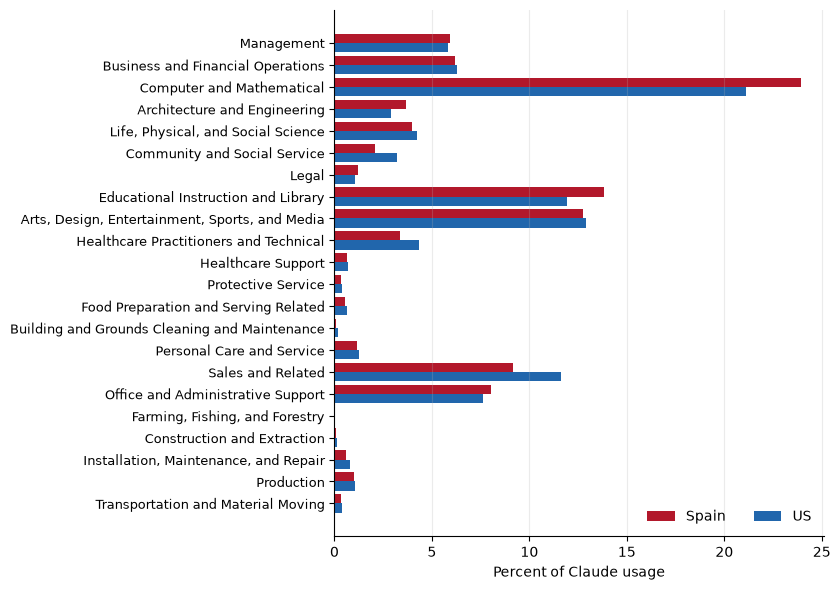

Saved filtered table: C:\Users\ngonzalezp\OneDrive - AIREF\Escritorio\Unempolyment_Benefits\ai_unemployment_analysis\code\last_scripts\figuresNtables\table_anthropic_country_soc_major_group_spain_us_may2026.csv
Saved figure: C:\Users\ngonzalezp\OneDrive - AIREF\Escritorio\Unempolyment_Benefits\ai_unemployment_analysis\code\last_scripts\figuresNtables\figure_anthropic_country_soc_major_group_spain_us_may2026.png


geo_id,node_external_id,Job group,Spain (%),United States (%),Difference (p.p.)
0,11,Management,5.91,5.85,0.06
1,13,Business and Financial Operations,6.19,6.27,-0.08
2,15,Computer and Mathematical,23.92,21.13,2.79
3,17,Architecture and Engineering,3.67,2.91,0.76
4,19,"Life, Physical, and Social Science",3.99,4.23,-0.24
5,21,Community and Social Service,2.07,3.20,-1.13
6,23,Legal,1.22,1.04,0.18
7,25,Educational Instruction and Library,13.83,11.92,1.91
8,27,"Arts, Design, Entertainment, Sports, and Media",12.75,12.91,-0.16
9,29,Healthcare Practitioners and Technical,3.36,4.33,-0.97


In [12]:
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError("Could not locate the package directory containing data/.")
RAW_DIR = PROJECT_ROOT / "data" / "raw"
TABLES_DIR = PROJECT_ROOT / "figuresNtables"
FIGURES_DIR = PROJECT_ROOT / "figuresNtables"

RAW_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

AEI_URL = "https://huggingface.co/datasets/Anthropic/EconomicIndex/resolve/main/release_2026_06_26/data/aei_claude_ai_2026-06-26.csv"
AEI_RAW_PATH = RAW_DIR / "anthropic_aei_claude_ai_2026-06-26.csv"
FILTERED_PATH = TABLES_DIR / "table_anthropic_country_soc_major_group_spain_us_may2026.csv"
FIGURE_PATH = FIGURES_DIR / "figure_anthropic_country_soc_major_group_spain_us_may2026.png"

# Download the raw Anthropic Economic Index release if it is not already present.
if not AEI_RAW_PATH.exists():
    urllib.request.urlretrieve(AEI_URL, AEI_RAW_PATH)

usecols = [
    "date_start",
    "date_end",
    "geo_id",
    "geo_level",
    "category_name",
    "hierarchy_level",
    "metric_id",
    "value",
    "node_name",
    "node_external_id",
]

pieces = []
for chunk in pd.read_csv(AEI_RAW_PATH, usecols=usecols, chunksize=500_000):
    keep = (
        chunk["date_start"].eq("2026-05-01")
        & chunk["date_end"].eq("2026-06-01")
        & chunk["geo_id"].isin(["ESP", "USA"])
        & chunk["geo_level"].eq("country")
        & chunk["category_name"].eq("soc_occupation")
        & chunk["hierarchy_level"].eq(1)
        & chunk["metric_id"].eq("pct")
    )
    sub = chunk.loc[keep].copy()
    if not sub.empty:
        pieces.append(sub)

country_soc = pd.concat(pieces, ignore_index=True)

plot_df = (
    country_soc
    .pivot_table(index=["node_external_id", "node_name"], columns="geo_id", values="value", aggfunc="first")
    .reset_index()
    .sort_values("node_external_id")
)
plot_df["Difference (p.p.)"] = plot_df["ESP"] - plot_df["USA"]
plot_df = plot_df.rename(columns={"node_name": "Job group", "ESP": "Spain (%)", "USA": "United States (%)"})
plot_df.to_csv(FILTERED_PATH, index=False)

x = np.arange(len(plot_df))
height = 0.42

fig, ax = plt.subplots(figsize=(8.5, 6.0))
ax.barh(
    x - height / 2,
    plot_df["Spain (%)"],
    height,
    label="Spain",
    color="#b2182b",
)
ax.barh(
    x + height / 2,
    plot_df["United States (%)"],
    height,
    label="US",
    color="#2166ac",
)

ax.set_xlabel("Percent of Claude usage")
ax.set_ylabel("")
ax.set_yticks(x)
ax.set_yticklabels(plot_df["Job group"], fontsize=9)
ax.invert_yaxis()
ax.legend(frameon=False, ncol=2, loc="lower right")
ax.grid(axis="x", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_PATH, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved filtered table: {FILTERED_PATH}")
print(f"Saved figure: {FIGURE_PATH}")

display(plot_df)


## Descriptive-output manifest\n\nRecord the publication artifacts created by this notebook. This manifest is used by the final tuning stage and by descriptive.tex.


In [13]:

descriptive_outputs = sorted(
    path for path in (PROJECT_ROOT / "figuresNtables").iterdir()
    if path.is_file() and (
        path.name.startswith("figure_")
        or path.name in {"summary_statistics.tex", "table_top_bottom_exposure_appendix.tex"}
    )
)
pd.DataFrame(
    [{"file": path.name, "bytes": path.stat().st_size} for path in descriptive_outputs]
).to_csv(PROJECT_ROOT / "intermediate" / "descriptive_artifact_manifest_v1.csv", index=False)
print(f"Descriptive stage complete: {len(descriptive_outputs)} publication artifacts.")
print("Next: run 03_Estimates_TWFE_SDID_HonestDID_v1.do.")


Descriptive stage complete: 5 publication artifacts.
Next: run 03_Estimates_TWFE_SDID_HonestDID_v1.do.
